# Predikcija otkazivanja hotelskih rezervacija primenom neuronskih mreža i algoritama mašinskog učenja

# Biblioteke

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# EDA

Cilj ovog dela je uočavanje obrazaca, razumevanje podataka i pronalaženje mogućih anomalija u podacima.

In [2]:
df = pd.read_csv("data/hotel_booking.csv")
print(f"Broj redova: {df.shape[0]}, broj kolona: {df.shape[1]}")

Broj redova: 119390, broj kolona: 36


In [3]:
print(f"Kolone: {df.columns.to_list()}")

Kolone: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card']


In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


Kolone name, email, phone-number i credit_card predstavljaju sintetičke ili privatne identifikatore korisnika koji nemaju prediktivnu moć i biće uklonjeni.

Curenje podataka: Kolone reservation_status (Check-Out, Canceled, No-Show) i reservation_status_date direktno otkrivaju ishod boravka. U realnom scenariju predikcije ove informacije nisu poznate u trenutku rezervacije, te se moraju ukloniti pre obučavanja modela.

In [5]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


**Uočena anomalija**

Kolona "adr" (prosečna dnevna cena): Minimalna vrednost je -6.38 (negativna cena noćenja je logička greška u podacima). Maksimalna vrednost: 5400.00 (ekstremni autlajer u odnosu na medijanu od 94.58).

In [6]:
df.loc[df['adr'] < 0].shape[0]

1

In [7]:
df['adr'].nlargest(5)

48515     5400.0
111403     510.0
15083      508.0
103912     451.5
13142      450.0
Name: adr, dtype: float64

In [8]:
df.loc[df['adr'] > 510].shape[0]

1

Ekstremne minimalne i maksimalne vrednosti za 'adr' su retke(po jedan primerak). Bezbedno ih je onda ukloniti kako ne bi narušili skaliranje za modele

In [9]:
(df.loc[(df['adults']==0) & (df['babies']==0) & (df['children']==0)]).shape[0]

180

In [10]:
df.loc[df['adults']< 1].shape[0]

403

**Logička nekonzistentnost**

Pristutne su rezervacije gde je ukupan broj odraslih, dece i beba jednak 0 što predstavlja nevalidne unose.

Primećujemo i da je mnogo veći broj redova gde je broj odraslih jednak nuli. Deca ili bebe ne mogu sami rezervisati niti boraviti u hotelu bez odrasle osobe.

Ove redove najbolje ukloniti, kako modeli ne bi učili iz šuma, 403 od 119390 redova je zanemarljiv gubitak.

In [11]:
df.loc[df['babies'] > 2, ['babies', 'children', 'adults', 'customer_type']]

,babies,children,adults,customer_type
46619,10,0.0,2,Transient
78656,9,0.0,1,Transient-Party


In [12]:
df.loc[df['children'] > 3, ['babies', 'children', 'adults', 'customer_type']]

,babies,children,adults,customer_type
328,0,10.0,2,Contract


**Logička nemogućnost**

Dvoje odraslih da čuva 9-10 dece ili beba van grupne organizacije je nerealistično. Ovi podaci će biti uklonjeni.

In [13]:
df.describe(include = 'object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926,81503,115889,119390,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,669-792-1661,************3627
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461,48,6,1,28


reserved_room_type i assigned_room_type imaju drugačiji broj unikatnih vrednosti, hotel verovatno ima sobe koje ne prikazuje javnosti pri rezervaciji

In [14]:
print(df.dtypes)

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [15]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
print("Kolone sa nedostajucim vrednostima")
missing_df = pd.DataFrame({"Broj nedostajucih vrednosti": missing, "Procenat": missing_percent})
display(missing_df)

Kolone sa nedostajucim vrednostima


,Broj nedostajucih vrednosti,Procenat
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350


Obeležje "company" ima ogroman procenat nedostajućih vrednosti što ukazuje na to da većina rezervacija nije napravljena preko kompanija. Kolona u izvornom obliku nije upotrebljiva i zahteva uklanjanje.

Nedostajuće vrednosti za kolonu "agent" ukazuje na direktne rezervacije(bez posredovanja agencije). Nedostajuće vrednosti mogu biti zamenjene sa 0.

Kolone "country" i "children" imaju zanemarljiv procenat nedostajućih vrednosti. Država se može zameniti posebnom kategorijom "Unknown", vrednost za decu 0 (većinski prisutna vrednost za tu kolonu).

In [16]:
print(f"Broj duplikata {df.duplicated().sum()}")

Broj duplikata 0


In [17]:
numerical_cols = df.select_dtypes(include= 'number').columns.to_list()
categorical_cols = df.select_dtypes(include='object').columns.to_list()
print(f"Numericke kolone: {numerical_cols}")
print(f"Kategoricke kolone: {categorical_cols}")

Numericke kolone: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Kategoricke kolone: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number', 'credit_card']


In [18]:
cat_summary = pd.DataFrame([
    {
        'Kolona': c,
        'Broj unikatnih': df[c].nunique(),
        'Unikatne vrednosti': list(df[c].unique())
    }
    for c in categorical_cols
])

display(cat_summary)

,Kolona,Broj unikatnih,Unikatne vrednosti
0,hotel,2,"[Resort Hotel, City Hotel]"
1,arrival_date_month,12,"[July, August, September, October, November, D..."
2,meal,5,"[BB, FB, HB, SC, Undefined]"
3,country,177,"[PRT, GBR, USA, ESP, IRL, FRA, nan, ROU, NOR, ..."
4,market_segment,8,"[Direct, Corporate, Online TA, Offline TA/TO, ..."
5,distribution_channel,5,"[Direct, Corporate, TA/TO, Undefined, GDS]"
6,reserved_room_type,10,"[C, A, D, E, G, F, H, L, P, B]"
7,assigned_room_type,12,"[C, A, D, E, G, F, I, B, H, P, L, K]"
8,deposit_type,3,"[No Deposit, Refundable, Non Refund]"
9,customer_type,4,"[Transient, Contract, Transient-Party, Group]"


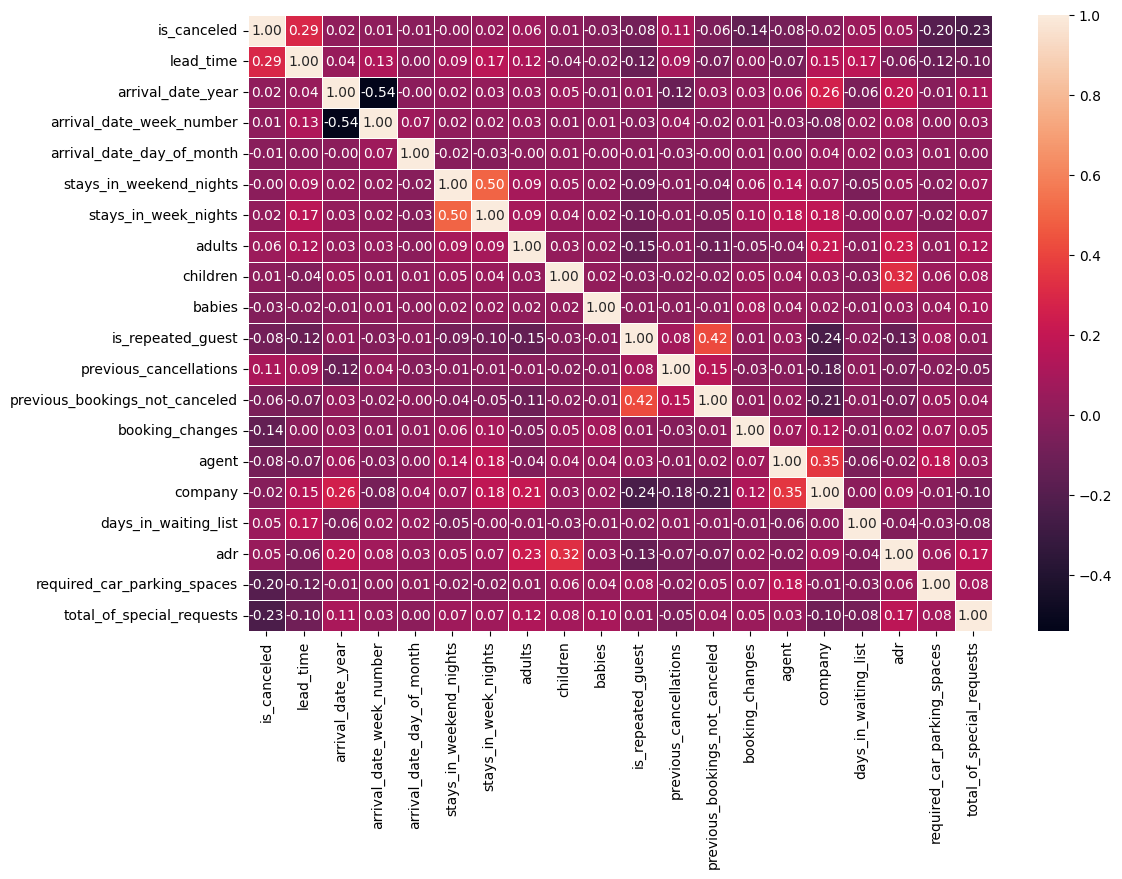

In [19]:
corr_mat = df[numerical_cols].corr()
plt.figure(figsize=(12, 8))
sb.heatmap(
    corr_mat,
    annot = True,
    fmt = '.2f',
    linewidths= 0.4
)
plt.show()

Korelaciona matrica  pokazuje uglavnom slabu međusobnu linearnu zavisnost, što odgovara modelima jer izbegava multikolinearnost. 

Uočene su dve umerene korelacije:
    
1. arrival_date_year i arrival_date_week_number: Očekivana korelacija usled načina na koji su podaci prikupljani kroz godine i kalendarske nedelje.

2. previous_bookings_not_canceled i is_repeated_guest: Logična pozitivna korelacija, povratni gosti po pravilu imaju prethodno realizovane rezervacije.

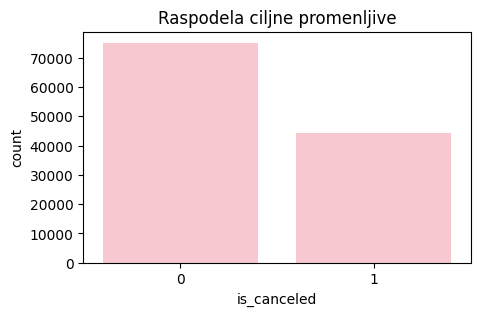

is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64

In [20]:
plt.figure(figsize=(5,3))
sb.countplot(x='is_canceled', data=df, color='pink')
plt.title('Raspodela ciljne promenljive')
plt.show()
df['is_canceled'].value_counts(normalize=True) * 100

Prisutan je blagi disbalans klasa. Disbalans nije kritičan, ali diktira primenu metrika kao što su F1-score, Precision, Recall umesto samo tačnosti (Accuracy).

In [21]:
df['arrival_date_year'].value_counts()

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

In [22]:
df['agent'].value_counts()

agent
9.0      31961
240.0    13922
1.0       7191
14.0      3640
7.0       3539
         ...  
444.0        1
408.0        1
388.0        1
453.0        1
480.0        1
Name: count, Length: 333, dtype: int64

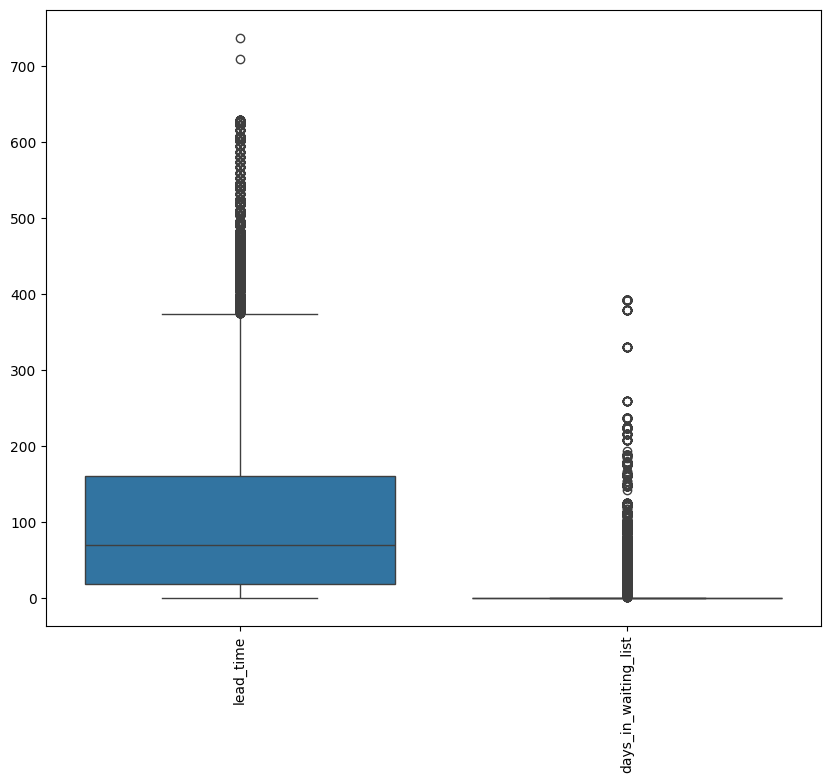

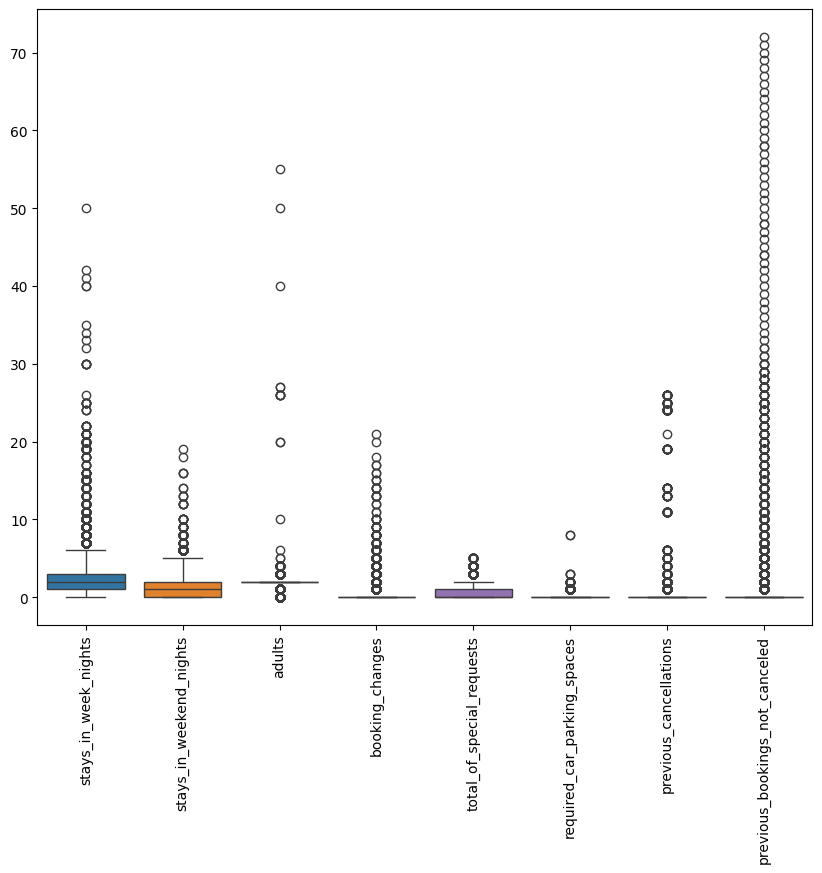

In [23]:
groups = {
    "longer": ['lead_time', 'days_in_waiting_list'],
    "shorter": ['stays_in_week_nights', 'stays_in_weekend_nights', 'adults', 'booking_changes',
                'total_of_special_requests', 'required_car_parking_spaces', 
        'previous_cancellations', 'previous_bookings_not_canceled']
    
}

for group_name, cols in groups.items():
    plt.figure(figsize=(10,8))
    sb.boxplot(data=df[groups[group_name]])
    plt.xticks(rotation=90)
    plt.show()

In [24]:
print("Raspodela 'customer_type' za veliki broj odraslih")
print(df[df['adults'] > 4]['customer_type'].value_counts())


Raspodela 'customer_type' za veliki broj odraslih
customer_type
Group    16
Name: count, dtype: int64


Autlajeri za broj odraslih samo označava grupne rezervacije.

Autlajera za broj noćenja ima dosta ali to jesu realne brojke, neki gosti bukiraju duže boravke od par meseci. 

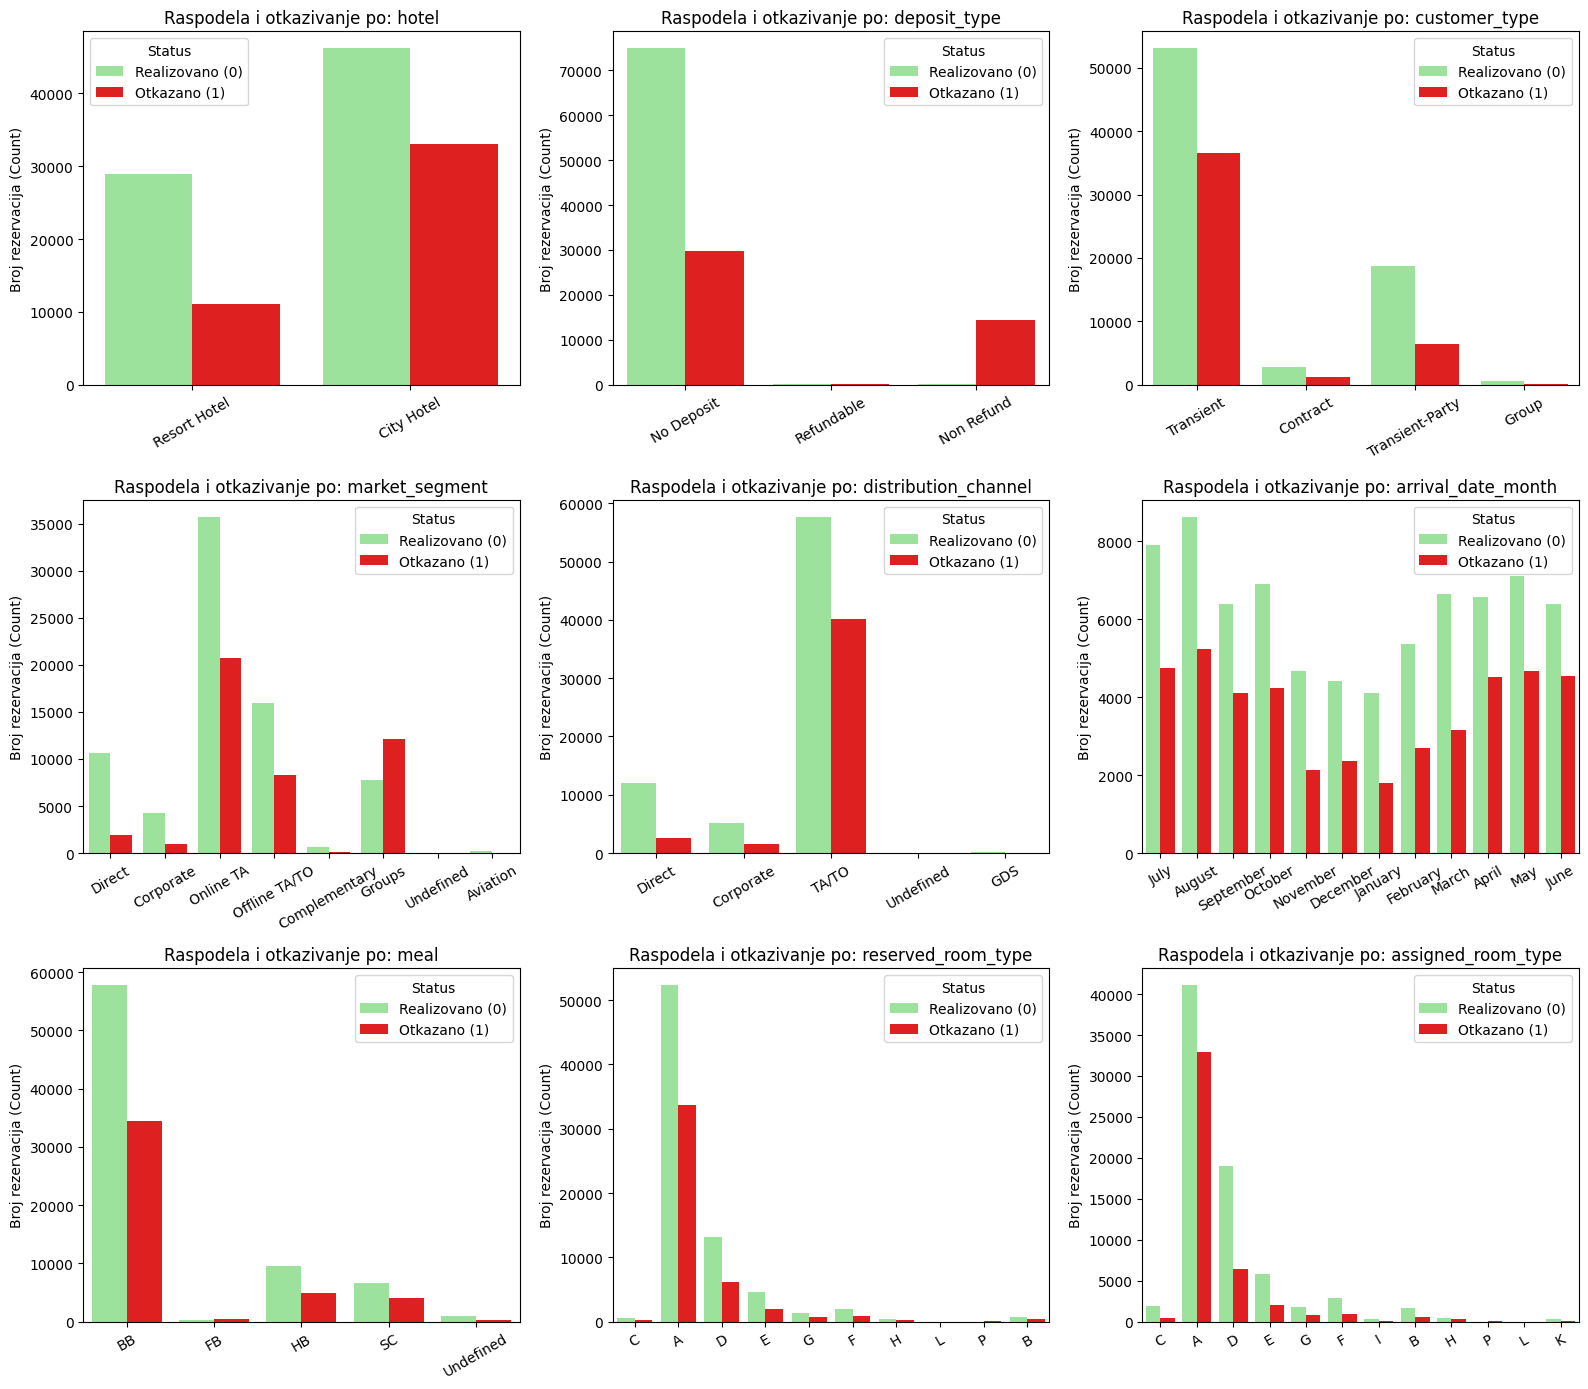

In [25]:
cols_to_plot = [
    'hotel', 'deposit_type', 'customer_type', 
    'market_segment', 'distribution_channel', 'arrival_date_month', 'meal', 'reserved_room_type', 'assigned_room_type'
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    sb.countplot( data=df, x=col, hue='is_canceled', ax=ax, palette={0: 'lightgreen', 1: 'r'})
    
    ax.set_title(f'Raspodela i otkazivanje po: {col}')
    ax.set_ylabel('Broj rezervacija (Count)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(['Realizovano (0)', 'Otkazano (1)'], title='Status')
    

plt.tight_layout()
plt.show()

**Zapažanja**

Interesantno zapažanje je da kod rezervacija bez povrata novca dominira status "otkazano" dok je kod rezervacija bez ikakvog depozita obrnuta situacija.

Avgust je najdominantniji mesec za rezervaciju, dok su rezervacije slabije tokom zime.

Gradski hoteli imaju višu stopu otkazivanja od odmarališta. Iz druge perspektive: Gradski hoteli imaju veći broj rezervacija od rizorta, pa se može zaključiti da što je više  rezervacija, to je viša stopa otkazivanja.

Kod sobe "D" je češće dat kupcima nego što je rezervisan i obrnuto za sobu "A". Uočava se i promena statusa rezervacije zbog toga. Što ukazuje da gosti zbog upgrade-a/downgrade-a promene mišljenje.

Stopa otkazivanja je veća za Full Board plan ishrane

Rezervacije se najčešće vrše preko Online agencija. Kod grupnih rezervacija ima značajno više otkazivanja. Dok su "najuspešnije" direktne hotelske rezervacije.

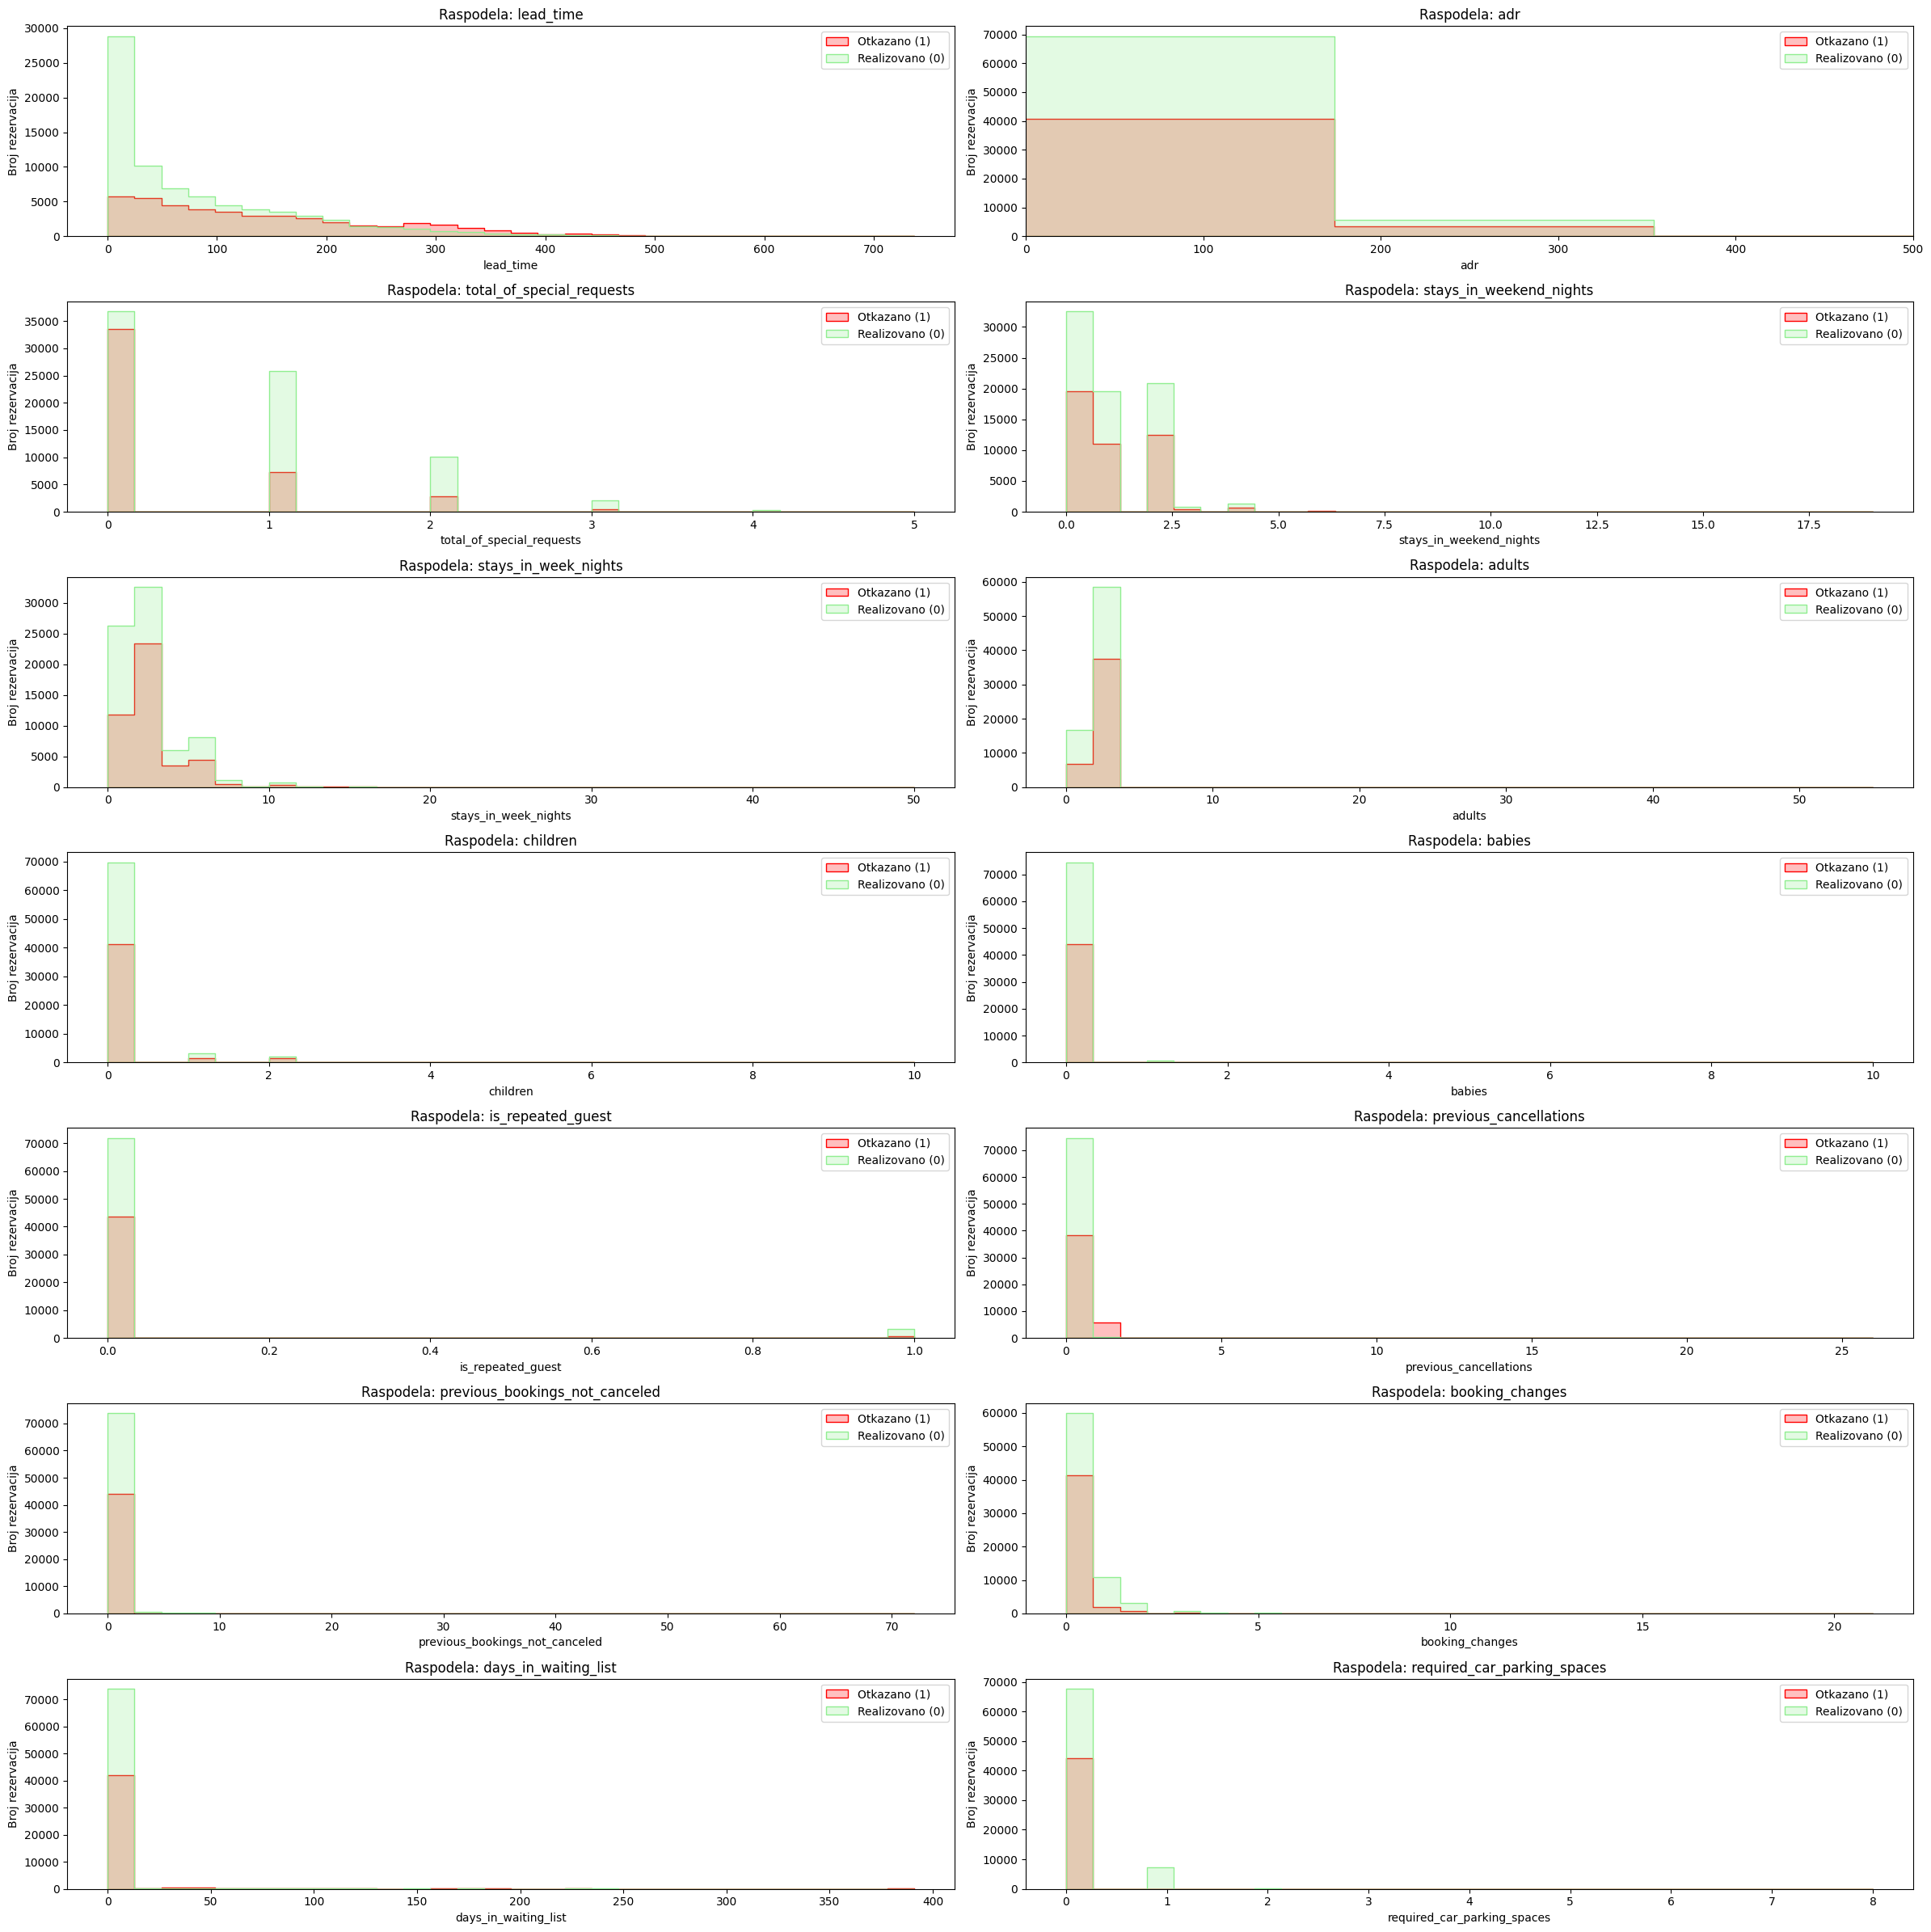

In [26]:
cols_to_plot = ['lead_time', 'adr', 'total_of_special_requests', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 
            'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes',
            'days_in_waiting_list', 'required_car_parking_spaces']

fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(24, 24))

axes = axes.flatten()
for i, col in enumerate(cols_to_plot):
    sb.histplot(data=df, x=col, hue='is_canceled', palette={0: 'lightgreen', 1: 'r'},element='step',bins=30,ax=axes[i])
    axes[i].set_title(f'Raspodela: {col}')
    axes[i].set_ylabel('Broj rezervacija')
    axes[i].legend(['Otkazano (1)', 'Realizovano (0)'])
    
    # Za adr autlajere, ograničavamo prikaz radi preglednosti
    if col == 'adr':
        axes[i].set_xlim(0, 500)
    

plt.tight_layout()
plt.show()

**Zapažanja**

Što je veći raspon između datuma rezervacije i dolaska, to je veća šansa otkazivanja.

Rezervacije bez posebnih zahteva imaju značajan broj otkazivanja. Slično i sa malim(ili nepostojećim) promenama rezervacije.

Ako je gost imao više od jednog prethodnog otkazivanja, sklon je ponovnom otkazivanju.

Gosti uglavnom ne dolaze više puta u isti hotel, već najviše rezervacija prave novi gosti.

Sa većim brojem rezervisanih radnih dana raste i šansa otkazivanja.

# Zaključak EDA

Ukloniti sve pomenute anomalije i autlajere

**Plan feature-a nakon analize**

Dodati:
1. room_mismatch binarni indikator dobijen poređenjem reserved_room_type i assigned_room_type, meri odstupanje od želja gosta.

Obrisati: 
1. name, email, phone-number, credit_card (nisu korisni za predikciju i vrednosti nisu prave)
2. company (94% nedostajućih vrednosti)
3. arrival_date_week_number (redundantno sa mesecom)
4. arrival_date_year (ako bi se model koristio u budućnosti, model obučen na godinama 2015, 2016, 2017 neće znati kako da tretira godinu 2026. Uklanjamo da model ne bi učio vremenski specifičan trend koji više ne važi)
5. arrival_date_day_of_month (sam po sebi nema jasno prediktivno značenje, sa 31 mogućom vrednošću, unosi dosta šuma)
6. reserved_room_type i assigned_room_type (kako ne bi dodali 20 novih indikatorskih kolona, najjači poslovni signal nije koje je tačno slovo sobe, već da li je gost dobio sobu koju je rezervisao.)

Transformacije:
1. country: Svodi se na TOP 10 najučestalijih zemalja, dok se ostale grupišu u kategoriju "Other"
2. frequency encoding za kolonu agent (ima preko 300 unikatnih vrednosti, one hot encoding nije resenje)

# Priprema podataka

In [3]:
df_clean = df.copy()

cols_to_drop = ['name', 'email', 'phone-number', 'credit_card', 'reservation_status', 'reservation_status_date',
                'company', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month']
df_clean.drop(columns=cols_to_drop, inplace=True)

df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['agent'] = df_clean['agent'].fillna(0)
df_clean['children'] = df_clean['children'].fillna(0)

df_clean = df_clean[(df_clean['adr'] > 0) & (df_clean['adr'] < 520)]
df_clean = df_clean[(df_clean['adults'] >= 1)]
df_clean = df_clean[(df_clean['children'] <= 3) & (df_clean['babies'] <= 2)]

In [4]:
df_clean['room_mismatch'] = (df_clean['reserved_room_type'] != df_clean['assigned_room_type']).astype(int)
df_clean['has_agent'] = (df_clean['agent'] != 0).astype(int)
df_clean.drop(columns=['reserved_room_type', 'assigned_room_type'], inplace=True)

In [5]:
top_countries = df_clean['country'].value_counts().nlargest(10).index
df_clean['country'] = df_clean['country'].apply(lambda x: x if x in top_countries else 'Other')

In [6]:
print(f"Broj redova nakon čišćenja: {df_clean.shape[0]}. Broj kolona: {df_clean.shape[1]}")

Broj redova nakon čišćenja: 117178. Broj kolona: 26


In [7]:
cols_for_dummies = ['hotel', 'meal', 'market_segment', 'distribution_channel',
                     'deposit_type', 'customer_type', 'country', 'arrival_date_month']
df_clean = pd.get_dummies(data=df_clean, columns=cols_for_dummies, drop_first=True, dtype=int)

In [8]:
X = df_clean.drop(columns=['is_canceled'])
y = df_clean['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)


In [9]:
agent_freq = X_train['agent'].value_counts(normalize=True).to_dict()

X_train['agent_freq'] = X_train['agent'].map(agent_freq).fillna(0)
X_test['agent_freq'] = X_test['agent'].map(agent_freq).fillna(0)

X_train.drop(['agent'], axis=1, inplace=True)
X_test.drop(['agent'], axis=1, inplace=True)

In [10]:
cols_for_scaling = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
                 'adults', 'children', 'babies',
                 'previous_cancellations', 'previous_bookings_not_canceled',
                 'booking_changes', 'days_in_waiting_list', 'adr',
                 'required_car_parking_spaces', 'total_of_special_requests', 'agent_freq']

scaler = StandardScaler()
X_train[cols_for_scaling] = scaler.fit_transform(X_train[cols_for_scaling])
X_test[cols_for_scaling] = scaler.transform(X_test[cols_for_scaling])

In [11]:
print(f"X_train oblik: {X_train.shape}")
print(f"X_test oblik: {X_test.shape}")

X_train oblik: (93742, 59)
X_test oblik: (23436, 59)


# Pomoćna funkcija za evaluaciju modela

In [27]:
def evaluate_model(model, X_test, y_test, model_name, nn=False, display=True):
    if nn:
        y_pred_test = (model.predict(X_test) >= 0.5).astype(int)
        y_pred_train = (model.predict(X_train) >= 0.5).astype(int)
    else:
        y_pred_test = model.predict(X_test)
        y_pred_train = model.predict(X_train)
    if display:
        print(f"\n{'-'*50}")
        print(f"Rezultati(Test skup) za: {model_name}")
        print('-'*50)
        print(classification_report(y_test, y_pred_test, target_names=['Realizovano', 'Otkazano']))

        print(f"\n{'-'*50}")
        print(f"Rezultati(Train skup) za: {model_name}")
        print('-'*50)
        print(classification_report(y_train, y_pred_train, target_names=['Realizovano', 'Otkazano']))

        cm = confusion_matrix(y_test, y_pred_test)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['Realizovano', 'Otkazano'])
        disp.plot(cmap='Blues')
        plt.title(f'Matrica konfuzije: {model_name}')
        plt.show()

        print(cm)

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred_test),
        'precision': precision_score(y_test, y_pred_test),
        'recall': recall_score(y_test, y_pred_test),
        'f1': f1_score(y_test, y_pred_test),
        'train_f1': f1_score(y_train, y_pred_train)
    }

# Logistička regresija

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
log_reg_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'max_iter': [100, 500, 1000]
}

log_reg_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    log_reg_params,
    cv=cv,
    scoring='f1',    
    n_jobs=-1
)
log_reg_grid.fit(X_train, y_train)

print("Najbolji parametri (Logistička regresija):", log_reg_grid.best_params_)
best_log_reg = log_reg_grid.best_estimator_

Najbolji parametri (Logistička regresija): {'C': 10, 'max_iter': 100, 'penalty': 'l2'}



--------------------------------------------------
Rezultati(Test skup) za: Logistička regresija
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.83      0.91      0.87     14650
    Otkazano       0.82      0.70      0.75      8786

    accuracy                           0.83     23436
   macro avg       0.83      0.80      0.81     23436
weighted avg       0.83      0.83      0.83     23436


--------------------------------------------------
Rezultati(Train skup) za: Logistička regresija
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.83      0.90      0.87     58601
    Otkazano       0.81      0.70      0.75     35141

    accuracy                           0.82     93742
   macro avg       0.82      0.80      0.81     93742
weighted avg       0.82      0.82      0.82     93742



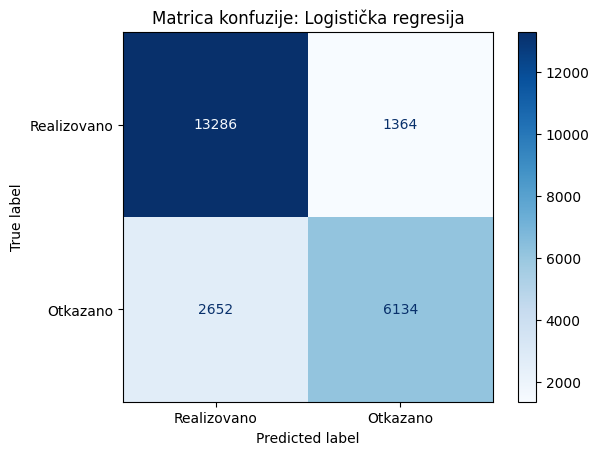

[[13286  1364]
 [ 2652  6134]]


{'model': 'Logistička regresija',
 'accuracy': 0.8286396996074415,
 'precision': 0.8180848226193652,
 'recall': 0.6981561575233326,
 'f1': 0.7533775485138786,
 'train_f1': 0.748892081053822}

In [19]:
evaluate_model(best_log_reg, X_test, y_test, "Logistička regresija")

Train i test rezultati su praktično identični, model ne overfituje.

Model bolje prepoznaje "Realizovano" nego "Otkazano" - recall 0.91 vs 0.70.

False Negative (2652 slučaja) je verovatno skuplja greška od False Positive (1364), jer propušten "otkazano" znači da hotel ne preduzima meru za gosta koji će zapravo otkazati.

# Random Forest

In [45]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [1, 2, 5],
    'min_samples_leaf': [1, 2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Najbolji parametri (Random Forest):", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

Najbolji parametri (Random Forest): {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}



--------------------------------------------------
Rezultati(Test skup) za: Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.87      0.94      0.90     14650
    Otkazano       0.88      0.76      0.82      8786

    accuracy                           0.87     23436
   macro avg       0.87      0.85      0.86     23436
weighted avg       0.87      0.87      0.87     23436


--------------------------------------------------
Rezultati(Train skup) za: Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.88      0.94      0.91     58601
    Otkazano       0.89      0.78      0.83     35141

    accuracy                           0.88     93742
   macro avg       0.88      0.86      0.87     93742
weighted avg       0.88      0.88      0.88     93742



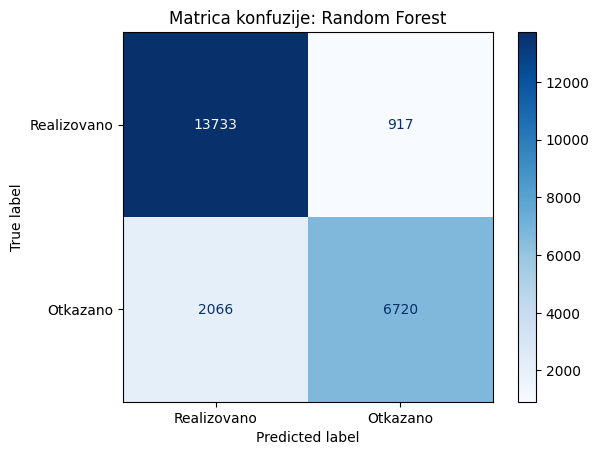

[[13733   917]
 [ 2066  6720]]


{'model': 'Random Forest',
 'accuracy': 0.8727171872333163,
 'precision': 0.8799266727772685,
 'recall': 0.7648531755064876,
 'f1': 0.8183644888266456,
 'train_f1': 0.8316667170176127}

In [46]:
evaluate_model(best_rf, X_test, y_test, "Random Forest")

RF znatno bolje hvata manjinsku klasu (recall 0.70(LR) -> 0.83), verovatno zato što uspeva da nauči nelinearne interakcije.

False Negative pao sa 2652 (LR) na 1511 (RF) - 43% manje propuštenih otkazivanja.

                        feature  importance
32      deposit_type_Non Refund    0.169607
46                  country_PRT    0.135689
0                     lead_time    0.103501
58                   agent_freq    0.076697
13    total_of_special_requests    0.073596
7        previous_cancellations    0.049482
14                room_mismatch    0.048637
12  required_car_parking_spaces    0.034633
11                          adr    0.028182
26     market_segment_Online TA    0.026628


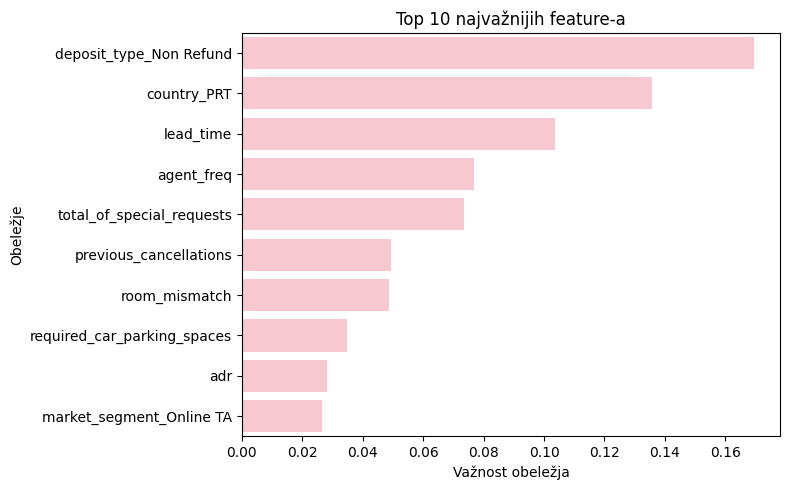

In [47]:
importances = best_rf.feature_importances_

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

plt.figure(figsize=(8,5))
sb.barplot(x='importance', y='feature', data=feat_imp.head(10), color='pink')
plt.title('Top 10 najvažnijih feature-a')
plt.xlabel('Važnost obeležja')
plt.ylabel('Obeležje')
plt.tight_layout()
plt.show()


Što je veći razmak između trenutka rezervacije i dolaska, to je veći prostor za promenu planova gosta. Ovo se poklapa i sa prethodnim opažanjem u EDA delu.

Rezervacije bez povrata novca su značajan faktor pri otkazivanju iako je kontraintuitivan, takođe uočenu u EDA. 

Domaći (portugalski) gosti imaju sistemski višu stopu otkazivanja od ostatka.

Turističke agencije koje vrše rezervaciju su važan faktor pri odluci.

# Bazična višeslojna neuronska mreža

Cilj je uporediti da li dodatna kompleksnost mreže donosi bolje rezultate na ovom problemu.

Prvi model će biti jednostavan, sa jednim skrivenim slojem i bez regularizacije.

In [24]:
input_dim = X_train.shape[1]

nn1 = Sequential()
nn1.add(Input(shape=(input_dim,)))
nn1.add(Dense(32, activation='relu'))
nn1.add(Dense(1, activation='sigmoid'))

nn1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall')]
)

nn1.summary()
history_nn1 = nn1.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,953 (7.63 KB)

 Trainable params: 1,953 (7.63 KB)

 Non-trainable params: 0 (0.00 B)

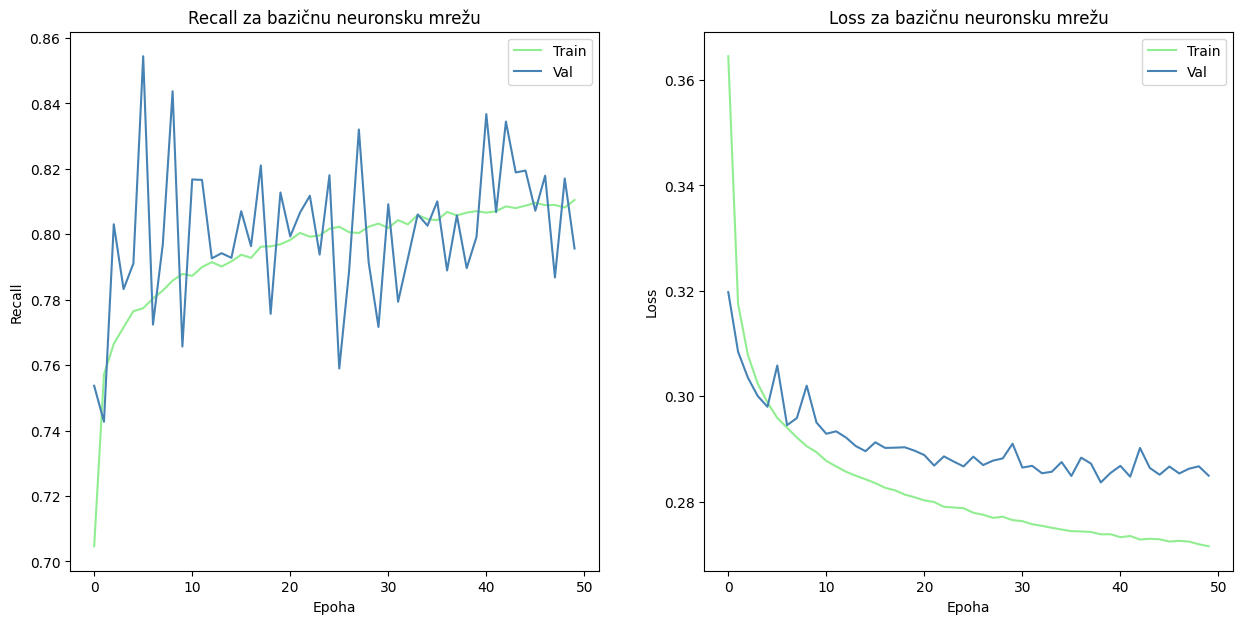

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(history_nn1.history['recall'], color='lightgreen', label='Train')
ax1.plot(history_nn1.history['val_recall'], color='steelblue', label='Val')
ax1.set_title('Recall za bazičnu neuronsku mrežu')
ax1.set_xlabel('Epoha')
ax1.set_ylabel('Recall')
ax1.legend()

ax2.plot(history_nn1.history['loss'], color='lightgreen', label='Train')
ax2.plot(history_nn1.history['val_loss'], color='steelblue', label='Val')
ax2.set_title('Loss za bazičnu neuronsku mrežu')
ax2.set_xlabel('Epoha')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

Loss: train linija je glatka i konstantno opada (0.26 na kraju), val linija je iznad nje sa blagim oscilacijama i stabilizuje se oko 0.29. Razlika između train i val loss-a je mala ali postoji, blagi znak overfitting-a. Model se i dalje dobro generalizuje na test set, ali ima prostora za poboljšanje regularizacijom.

Recall: train kriva glatko raste do 0.81, val kriva je nestabilna sa dosta oscilacija pre nego što završi na ~0.80.

733/733 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step

--------------------------------------------------
Rezultati(Test skup) za: Jednostavna VNM
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.88      0.92      0.90     14650
    Otkazano       0.85      0.79      0.82      8786

    accuracy                           0.87     23436
   macro avg       0.87      0.85      0.86     23436
weighted avg       0.87      0.87      0.87     23436


--------------------------------------------------
Rezultati(Train skup) za: Jednostavna VNM
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.88      0.92      0.90     58601
    Otkazano       0.85      0.80      0.83     35141

    accuracy                           0.87     93742
   macro avg       0.87      0.86      0.86     93742
weighted avg       0.87     

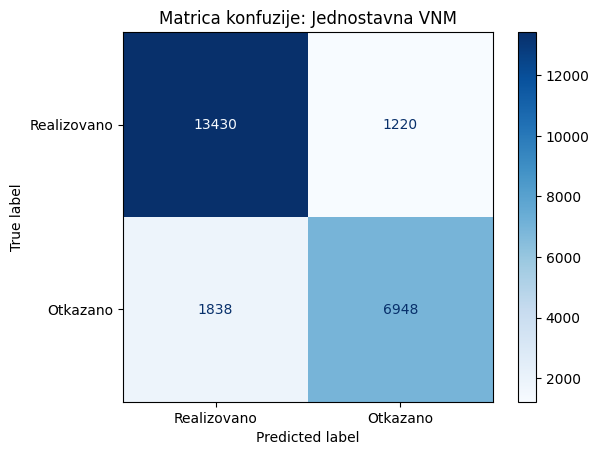

[[13430  1220]
 [ 1838  6948]]


{'model': 'Jednostavna VNM',
 'accuracy': 0.8695169824202083,
 'precision': 0.8506366307541626,
 'recall': 0.7908035511040291,
 'f1': 0.8196295859384216,
 'train_f1': 0.8260907888937858}

In [28]:
evaluate_model(nn1, X_test, y_test, "Jednostavna VNM", True)

# Složenija višeslojna neuronska mreža

Tri skrivena sloja i normalizacija.

In [31]:
input_dim = X_train.shape[1]

nn2 = Sequential()
nn2.add(Input(shape=(input_dim,)))
nn2.add(Dense(128, activation='relu'))
nn2.add(Dropout(0.3))
nn2.add(Dense(64, activation='relu'))
nn2.add(Dropout(0.3))
nn2.add(Dense(32, activation='relu'))
nn2.add(Dropout(0.2))
nn2.add(Dense(1, activation='sigmoid'))

nn2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall')]
)

nn2.summary()
history_nn2 = nn2.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,049 (70.50 KB)

 Trainable params: 18,049 (70.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8263 - loss: 0.3676 - precision: 0.8113 - recall: 0.6997 - val_accuracy: 0.8536 - val_loss: 0.3129 - val_precision: 0.8155 - val_recall: 0.7862
Epoch 2/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.8475 - loss: 0.3239 - precision: 0.8255 - recall: 0.7525 - val_accuracy: 0.8587 - val_loss: 0.3045 - val_precision: 0.8249 - val_recall: 0.7894
Epoch 3/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.8540 - loss: 0.3126 - precision: 0.8286 - recall: 0.7702 - val_accuracy: 0.8627 - val_loss: 0.2959 - val_precision: 0.8363 - val_recall: 0.7865
Epoch 4/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8559 - loss: 0.3058 - precision: 0.8305 - recall: 0.7740 - val_accuracy: 0.8632 - val_loss: 0.2969 - val_precision: 0.8167 - val_recall: 0.8175
Epoch 5/50
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8588 - loss: 0.3012 - precision: 0.8325 - recall: 0.7805 - val_accuracy: 0.8687

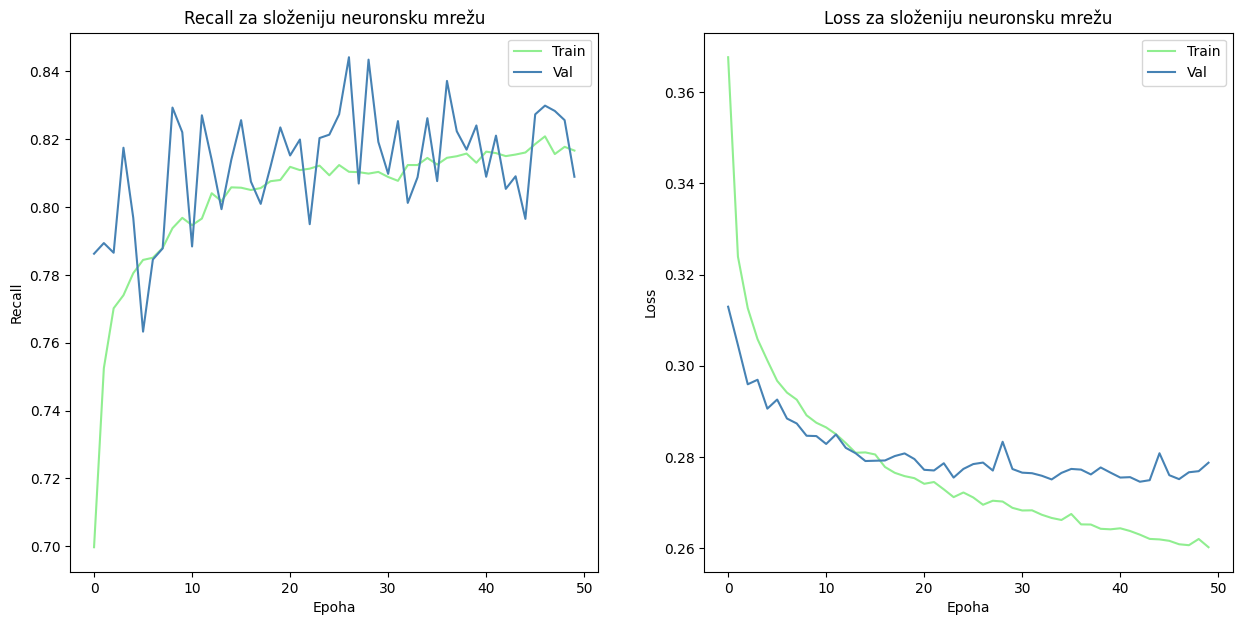

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(history_nn2.history['recall'], color='lightgreen', label='Train')
ax1.plot(history_nn2.history['val_recall'], color='steelblue', label='Val')
ax1.set_title('Recall za složeniju neuronsku mrežu')
ax1.set_xlabel('Epoha')
ax1.set_ylabel('Recall')
ax1.legend()

ax2.plot(history_nn2.history['loss'], color='lightgreen', label='Train')
ax2.plot(history_nn2.history['val_loss'], color='steelblue', label='Val')
ax2.set_title('Loss za složeniju neuronsku mrežu')
ax2.set_xlabel('Epoha')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

Recall: val kriva je i dalje oscilatorna, ali je primetno bliža train krivi nego kod jednostavnog modela, i sa manjim rasponom oscilacija. Ovo je direktan efekat dropout-a, smanjuje razmak između train i val performansi.

Loss: slično kao i kod bazične mreže.

733/733 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step

--------------------------------------------------
Rezultati(Test skup) za: Složenija VNM
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.89      0.92      0.90     14650
    Otkazano       0.86      0.80      0.83      8786

    accuracy                           0.88     23436
   macro avg       0.87      0.86      0.87     23436
weighted avg       0.88      0.88      0.88     23436


--------------------------------------------------
Rezultati(Train skup) za: Složenija VNM
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.90      0.93      0.91     58601
    Otkazano       0.87      0.82      0.85     35141

    accuracy                           0.89     93742
   macro avg       0.89      0.88      0.88     93742
weighted avg       0.89      0.8

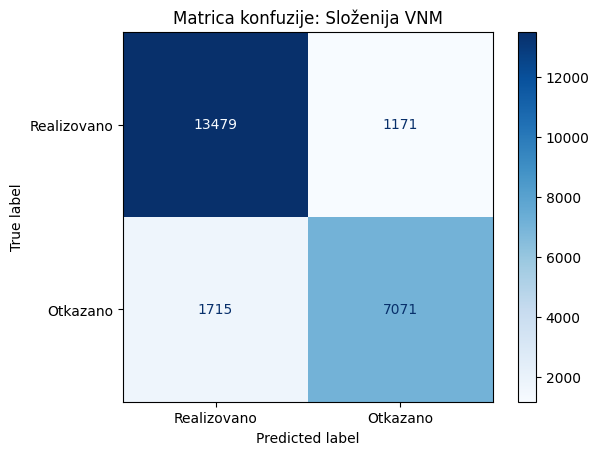

[[13479  1171]
 [ 1715  7071]]


{'model': 'Složenija VNM',
 'accuracy': 0.8768561187916026,
 'precision': 0.8579228342635282,
 'recall': 0.8048030958342818,
 'f1': 0.8305144467935166,
 'train_f1': 0.8474064519911472}

In [33]:
evaluate_model(nn2, X_test, y_test, "Složenija VNM", True)

Blago poboljšanje u odnosu na jednostavnu mrežu, recall skočio sa 0.81 na 0.83, F1 sa 0.82 na 0.83, accuracy sa 0.87 na 0.88. Dodatna kompleksnost je donela skroman napredak. Sada je kompleksna VNM izjednačena sa Random Forest-om po recall-u (0.83).

# Eksperimentalna neuronska mreža

Korišćenje EarlyStopping funkcije i povećanje dropout-a.

In [41]:
input_dim = X_train.shape[1]

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
nn3 = Sequential()
nn3.add(Input(shape=(input_dim,)))
nn3.add(Dense(128, activation='relu'))
nn3.add(Dropout(0.4))
nn3.add(Dense(64, activation='relu'))
nn3.add(Dropout(0.4))
nn3.add(Dense(32, activation='relu'))
nn3.add(Dropout(0.2))
nn3.add(Dense(1, activation='sigmoid'))

nn3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'),
                keras.metrics.Recall(name='recall')]
)

history_nn3 = nn3.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=0, callbacks=[early_stop])

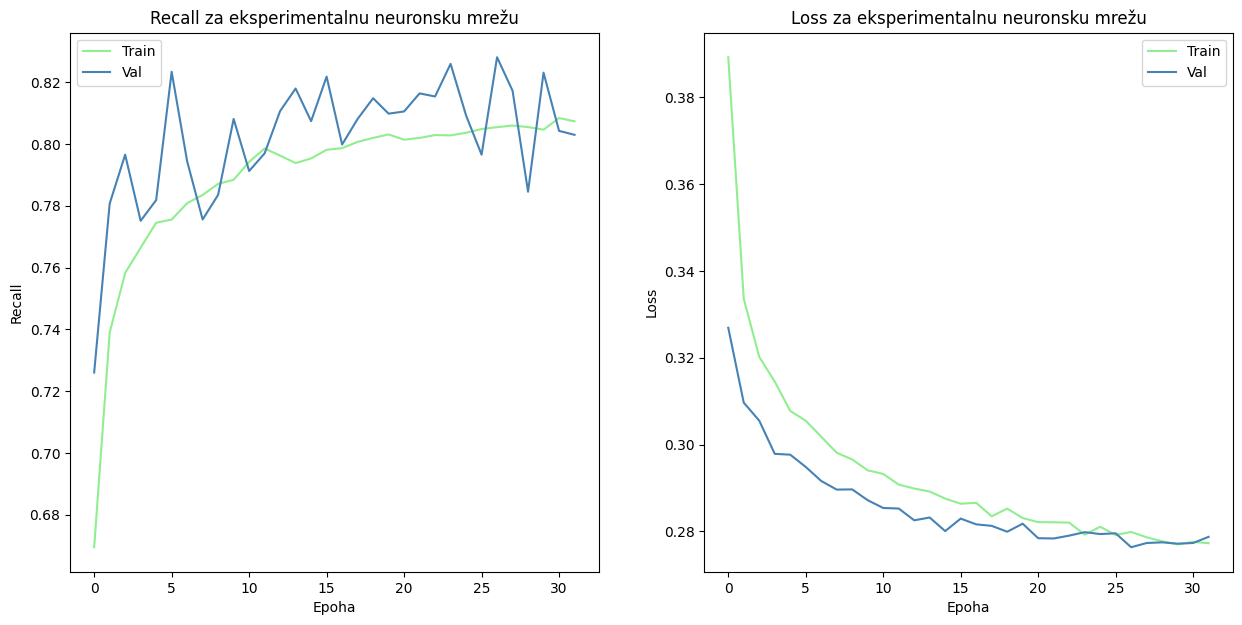

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

ax1.plot(history_nn3.history['recall'], color='lightgreen', label='Train')
ax1.plot(history_nn3.history['val_recall'], color='steelblue', label='Val')
ax1.set_title('Recall za eksperimentalnu neuronsku mrežu')
ax1.set_xlabel('Epoha')
ax1.set_ylabel('Recall')
ax1.legend()

ax2.plot(history_nn3.history['loss'], color='lightgreen', label='Train')
ax2.plot(history_nn3.history['val_loss'], color='steelblue', label='Val')
ax2.set_title('Loss za eksperimentalnu neuronsku mrežu')
ax2.set_xlabel('Epoha')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

EarlyStopping: sprečio je dalje treniranje u zoni gde bi model počeo overfitovati, bez gubitka performansi, znatno manje epoha.

Loss kriva se sada stabilnije spušta.

Niža vrednost recalla pri kraju je verovatno kombinovani efekat jačeg dropout-a (0.4) koji je usporio učenje baš u trenutku kad je EarlyStopping prekinuo trening.

733/733 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 3s 897us/step

--------------------------------------------------
Rezultati(Test skup) za: Eksperimentalna VNM
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.89      0.90      0.90     14650
    Otkazano       0.84      0.82      0.83      8786

    accuracy                           0.87     23436
   macro avg       0.87      0.86      0.86     23436
weighted avg       0.87      0.87      0.87     23436


--------------------------------------------------
Rezultati(Train skup) za: Eksperimentalna VNM
--------------------------------------------------
              precision    recall  f1-score   support

 Realizovano       0.90      0.91      0.90     58601
    Otkazano       0.84      0.84      0.84     35141

    accuracy                           0.88     93742
   macro avg       0.87      0.87      0.87     93742
weighted avg    

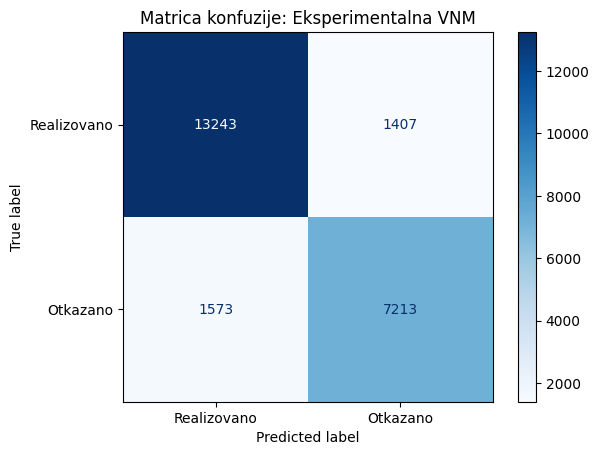

[[13243  1407]
 [ 1573  7213]]


{'model': 'Eksperimentalna VNM',
 'accuracy': 0.8728451954258406,
 'precision': 0.8367749419953596,
 'recall': 0.8209651718643296,
 'f1': 0.8287946685051132,
 'train_f1': 0.8402116402116402}

In [43]:
evaluate_model(nn3, X_test, y_test, "Eksperimentalna VNM", True)

# Upoređivanje metrika i zaključak

In [48]:
results = []
results.append(evaluate_model(best_log_reg, X_test, y_test, "Logistička regresija", display=False))
results.append(evaluate_model(best_rf, X_test, y_test, "Random Forest", display=False))
results.append(evaluate_model(nn1, X_test, y_test, "Jednostavna VNM", True, display=False))
results.append(evaluate_model(nn2, X_test, y_test, "Složenija VNM", True, display=False))
results.append(evaluate_model(nn3, X_test, y_test, "Eksperimentalna VNM", True, display=False))
results_df = pd.DataFrame(results).set_index('model')
results_df['f1_gap'] = results_df['train_f1'] - results_df['f1']
print("\nUporedni pregled modela:")
display(results_df.round(2))

733/733 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 2s 680us/step
733/733 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 3s 989us/step
733/733 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 2s 825us/step

Uporedni pregled modela:


,accuracy,precision,recall,f1,train_f1,f1_gap
model,,,,,,
Logistička regresija,0.83,0.82,0.70,0.75,0.75,-0.00
Random Forest,0.87,0.88,0.76,0.82,0.83,0.01
Jednostavna VNM,0.87,0.85,0.79,0.82,0.83,0.01
Složenija VNM,0.88,0.86,0.80,0.83,0.85,0.02
Eksperimentalna VNM,0.87,0.84,0.82,0.83,0.84,0.01


Cilj i pristup: Rad je istražio predikciju otkazivanja hotelskih rezervacija na skupu od ~119000 rezervacija, kroz tri porodice modela: linearni (logistička regresija), ansambl (Random Forest) i neuronske mreže (tri arhitekture rastuće kompleksnosti). Pripremni deo je obuhvatio detaljno čišćenje podataka i feature engineering.

U poslovanju hotela, False Negative je najskuplja greška. Ako model predvidi da gost dolazi, a on otkaže, hotel ostaje sa praznom sobom i gubitkom prihoda.

Random Forest je najbolji model na ovom skupu podataka, sa najvišim F1-score-om i vodećim precision-om, uz recall izjednačen sa najboljom neuronskom mrežom. Sve tri neuronske arhitekture su međusobno vrlo blizu (F1 0.82-0.83), sugerišući da je dodatna arhitektonska kompleksnost (više slojeva, dropout, EarlyStopping) donela ograničen dodatni dobitak.

Najveći skok u performansama se dogodio prelaskom sa linearnog modela (LogReg) na bilo koji nelinearan model (RF ili bilo koja VNM), razlika koja potvrđuje da relacije u podacima nisu čisto linearne i da ih linearni model strukturno ne može uhvatiti.

Sa poslovne strane, model treba minimizovati False Negative (propušteno predviđanje otkazivanja) jer nosi veći operativni trošak (hotel ne preduzima preventivne mere). Random Forest ima najmanji broj takvih grešaka, čineći ga najboljim kandidatom za eventualnu praktičnu primenu.

Ograničenja i pravci za dalje istraživanje: Dataset pokriva samo dva hotela u jednoj zemlji (Portugal), pa generalizacija na druge tržišta nije garantovana.

